# Домашнее задание 3. Линейная интерполяция

## Введение

На практике физические свойства газа (вязкость, коэффициент сверхсжимаемости, объёмный коэффициент и др.) известны лишь в дискретных точках — из лабораторных измерений или табличных расчётов. Чтобы получить значение свойства при произвольном давлении, необходима **интерполяция**.

**Линейная интерполяция** — простейший и наиболее распространённый метод: между двумя соседними известными точками $(x_i,\, y_i)$ и $(x_{i+1},\, y_{i+1})$ значение приближается прямой линией:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

где $x_p$ — точка, в которой нужно найти значение, а $y_p$ — результат интерполяции.

## Задание

### Что нужно сделать

1. **Считать файл `interp_data.csv`** и загрузить данные давления и вязкости.

2. **Дополнить таблицу столбцами Z и Bg** — используя класс `Fluid` из ДЗ-2, рассчитать коэффициент сверхсжимаемости и объёмный коэффициент расширения для каждого давления при фиксированной температуре $T = 310$ К.

3. **Реализовать класс `LinearInterpolator`** — собственный линейный интерполятор **без использования** встроенных функций интерполяции (numpy, scipy, pandas и т.д.).
   - Класс инициализируется массивами `x` и `y`.
   - Метод `predict(xp)` возвращает интерполированное значение $y_p$ для заданного $x_p$.

4. **Сравнить свой интерполятор с `numpy.interp`** — построить графики, на которых видно совпадение (или расхождение) результатов.

---

## Часть 1. Загрузка и обогащение данных

Считайте файл `interp_data.csv`. Затем вставьте свой класс `Fluid` из ДЗ-2 (с реализованными методами `get_Z` и `get_Bg`) и создайте объект `Fluid` со своими параметрами из `hw2_data.csv`.

Для каждого давления из таблицы рассчитайте Z и Bg при $T = 310$ К и добавьте результаты как новые столбцы.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class Fluid:
    
    Pstd = 1
    Tstd = 293.15
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        
        self.rho_c = rho_c
        self.xa = xa / 100
        self.xy = xy / 100
        self.xe = 1 - xa - xy
        self.zstd = 1 - (0.0741 * rho_c - 0.006 - 0.063 * xa - 0.0575 * xy)**2
        self.Me = (24.05525 * self.zstd * rho_c - 28.0135 * xa - 44.01 * xy)/self.xe
        self.H = 128.64 + 47.479 * self.Me
        
    def get_Z(self, P: float, T: float) -> float:

        B1 = -0.425468 + 2.865 * 10**(-3) * T - 4.62073 * 10**(-6) * T**2 + (8.77118 * 10**(-4) - 5.56281 * 10**(-6) * T + 8.8151 * 10**(-9) * T**2) * self.H + (-8.24747 * 10**(-7) + 4.31436 * 10**(-9) * T - 6.08319 * 10**(-12) * T**2) * self.H**2
        B2 = -0.1446 + 7.4091 * 10**(-4) * T - 9.1195 * 10**(-7) * T**2
        B23 = -0.339693 + 1.61176 * 10**(-3) * T - 2.04429 * 10**(-6) * T**2
        B3 = -0.86834 + 4.0376 * 10**(-3) * T - 5.1657 * 10**(-6) * T**2
        C1 = -0.302488 + 1.95861 * 10**(-3) * T - 3.16302 * 10**(-6) * T**2 + (6.46422 * 10**(-4) - 4.22876 * 10**(-6) * T + 6.88157 * 10**(-9) * T**2) * self.H + (-3.32805 * 10**(-7) + 2.2316 * 10**(-9) * T - 3.67713 * 10**(-12) * T**2) * self.H**2
        C2 = 7.8498 * 10**(-3) - 3.9895 * 10**(-5) * T + 6.1187 * 10**(-8) * T**2
        C3 = 2.0513 * 10**(-3) + 3.4888 * 10**(-5) * T - 8.3703 * 10**(-8) * T**2
        C223 = 5.52066 * 10**(-3) - 1.68609 * 10**(-5) * T + 1.57169 * 10**(-8) * T**2
        C233 = 3.58783 * 10**(-3) + 8.06674 * 10**(-6) * T - 3.25798 * 10**(-8) * T**2
        B = 0.72 + 1.875 * 10**(-5) * (320 - T)**2
        C = 0.92 + 0.0013 * (T-270)
        Bm = self.xe**2 * B1 + self.xe * self.xa * B * (B1 + B2) - 1.73 * self.xe * self.xy * (B1 * B3)**0.5 + self.xa**2 * B2 + 2 * self.xa * self.xy * B23 + self.xy**2 * B3
        Cm = self.xe**3 * C1 + 3 * self.xe**2 * self.xa * C * (C1**2 * C2)**(1/3) + 2.76 * self.xe**2 * self.xy * (C1**2 * C3)**(1/3) + 3 * self.xe * self.xa**2 * C * (C1 * C2**2)**(1/3) + 6.6 * self.xe * self.xa * self.xy * (C1 * C2 * C3)**(1/3) + 2.76 * self.xe * self.xy**2 * (C1 * C3**2)**(1/3) + self.xa**3 * C2 + 3 * self.xa**2 * self.xy * C223 + 3 * self.xa * self.xy**2 * C233 + self.xy**3 * C3
        b = (10**3 * P / 10)/(2.7715 * T)
        B0 = b * Bm
        C0 = b**2 * Cm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 + (A0**2 - A1**3)**0.5)**(1/3)
        z = (1 + A2 + A1/A2)/3
        return z
        
    def get_Bg(self, P: float, T: float) -> float:

        z = self.get_Z(P, T)
        Bg = (self.Pstd * z * T) / (P * self.Tstd)
        return Bg
        
    def plot_Z(self, T_fixed = 310):
        
        Ps = list(range(1, 100))
        z = []
        for i in Ps:
            z.append(self.get_Z(i, T_fixed))
        fig, ax = plt.subplots()
        ax.grid()
        ax.set_xlabel('p, atm')
        ax.set_ylabel('z')
        plt.plot(Ps, z)
    
    def plot_Bg(self, T_fixed = 310):

        Ps = list(range(1, 100))
        bgs = []
        for i in Ps:
            bgs.append(self.get_Bg(i, T_fixed))
        fig, ax = plt.subplots()
        ax.grid()
        ax.set_xlabel('p, atm')
        ax.set_ylabel('bg')
        plt.plot(Ps, bgs)

df = pd.read_csv('interp_data.csv', sep=';')
display(df.head())
Ps = df['pressure, atm']
vi = df['viscosity, cP']

rho_c = 0.6799
xa = 0.6119
xy = 0.1395

fluid = Fluid(rho_c=rho_c, xa=xa, xy=xy)

T = 310
z = []
bgs = []
for i in Ps:
    z.append(fluid.get_Z(i, T))
    bgs.append(fluid.get_Bg(i, T))

,"pressure, atm","viscosity, cP"
0,1.000000,0.018312
1,3.010101,0.018321
2,5.020202,0.018330
3,7.030303,0.018339
4,9.040404,0.018349


[1.0, 3.01010101, 5.02020202, 7.03030303, 9.04040404, 11.05050505, 13.06060606, 15.07070707, 17.08080808, 19.09090909, 21.1010101, 23.11111111, 25.12121212, 27.13131313, 29.14141414, 31.15151515, 33.16161616, 35.17171717, 37.18181818, 39.19191919, 41.2020202, 43.21212121, 45.22222222, 47.23232323, 49.24242424, 51.25252525, 53.26262626, 55.27272727, 57.28282828, 59.29292929, 61.3030303, 63.31313131, 65.32323232, 67.33333333, 69.34343434, 71.35353535, 73.36363636, 75.37373737, 77.38383838, 79.39393939, 81.4040404, 83.41414141, 85.42424242, 87.43434343, 89.44444444, 91.45454545, 93.46464646, 95.47474747, 97.48484848, 99.49494949, 101.5050505, 103.5151515, 105.5252525, 107.5353535, 109.5454545, 111.5555556, 113.5656566, 115.5757576, 117.5858586, 119.5959596, 121.6060606, 123.6161616, 125.6262626, 127.6363636, 129.6464646, 131.6565657, 133.6666667, 135.6767677, 137.6868687, 139.6969697, 141.7070707, 143.7171717, 145.7272727, 147.7373737, 149.7474747, 151.7575758, 153.7676768, 155.7777778, 1

---

## Часть 2. Собственный интерполятор

Реализуйте класс `LinearInterpolator`.

### Требования

- `__init__(self, x, y)` — принимает два списка (или массива) одинаковой длины. Значения `x` должны быть отсортированы по возрастанию.
- `predict(self, xp)` — принимает скалярное значение `xp` и возвращает интерполированное значение `yp`.
- **Запрещено** использовать `numpy`, `scipy`, `pandas` и любые другие библиотечные функции интерполяции внутри класса. Только чистый Python (`list`, `for`, `if`, арифметика).

### Подсказка

Алгоритм для `predict(xp)`:
1. Найти индекс $i$ такой, что $x_i \le x_p < x_{i+1}$.
2. Применить формулу линейной интерполяции:

$$
y_p = y_i + \frac{y_{i+1} - y_i}{x_{i+1} - x_i} \cdot (x_p - x_i)
$$

> Что делать, если `xp` совпадает с последней точкой $x_n$? Обработайте этот граничный случай через экстраполяцию по двум граничным точкам

In [21]:
class LinearInterpolator:
    
    def __init__(self, x: list, y: list):

        if len(x) == len(y):
            xy = {'x': x, 'y': y}
            xy = pd.DataFrame(xy)
            xy.sort_values('x', ascending = True)
            self.x = list(xy['x'])
            self.y = list(xy['y'])
        else:
            print('Длины массивов должны быть одинаковыми')
            pass
    
    def predict(self, xp: float):

        for i in range(0, len(self.x)):
            if self.x[i] > xp:
                x2 = self.x[i]
                x1 = self.x[i-1]
                y2 = self.y[i]
                y1 = self.y[i-1]
                yp = y1 + (y2 - y1)/(x2 - x1)*(xp - x1)
                break
            elif self.x[i] == xp:
                yp = self.y[i]
            elif self.x[-1] == xp:
                x2 = self.x[i-1]
                x1 = self.x[i-2]
                y2 = self.y[i-1]
                y1 = self.y[i-2]
                yp = y1 + (y2 - y1)/(x2 - x1)*(xp - x1)
        return yp

---

## Часть 3. Сравнение с `numpy.interp`

Сгенерируйте набор промежуточных точек давления (например, 500 точек в диапазоне от 1 до 200 атм). Вычислите интерполированные значения **вязкости**, **Z** и **Bg** двумя способами:

1. Ваш `LinearInterpolator`
2. Функция `numpy.interp`

Постройте графики, на которых отображены:
- Исходные табличные точки (маркерами)
- Кривая вашего интерполятора
- Кривая `numpy.interp`

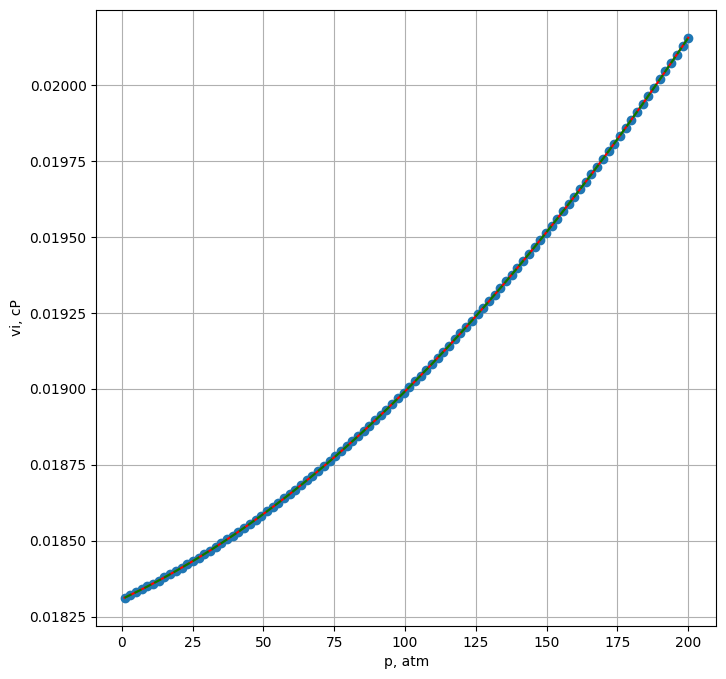

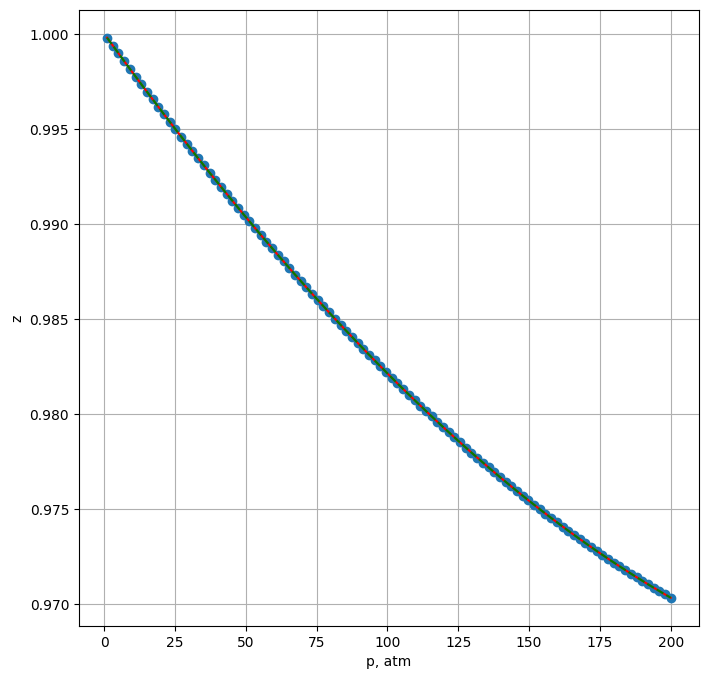

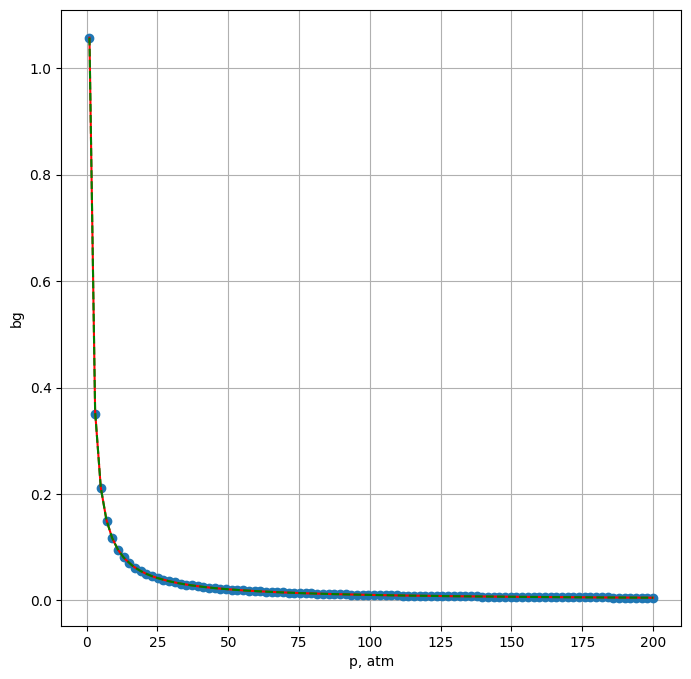

In [22]:
import random

Pr = []
for _ in range(500):
    Pr.append(random.randint(1, 200))
Pr = sorted(Pr)

vi_LI = []
z_LI = []
bgs_LI = []
for i in Pr:
    vi_LI.append(LinearInterpolator(Ps, vi).predict(i))
    z_LI.append(LinearInterpolator(Ps, z).predict(i))
    bgs_LI.append(LinearInterpolator(Ps, bgs).predict(i))

vi_NI = np.interp(Pr, Ps, vi)
z_NI = np.interp(Pr, Ps, z)
bgs_NI = np.interp(Pr, Ps, bgs)

plt.figure(figsize = (8,8))
plt.grid()
plt.xlabel('p, atm')
plt.ylabel('vi, cP')
plt.plot(Ps, vi, marker = 'o', linestyle = '')
plt.plot(Pr, vi_LI, color = 'red')
plt.plot(Pr, vi_NI, color = 'green', linestyle = '--')

plt.figure(figsize = (8,8))
plt.grid()
plt.xlabel('p, atm')
plt.ylabel('z')
plt.plot(Ps, z, marker = 'o', linestyle = '')
plt.plot(Pr, z_LI, color = 'red')
plt.plot(Pr, z_NI, color = 'green', linestyle = '--')

plt.figure(figsize = (8,8))
plt.grid()
plt.xlabel('p, atm')
plt.ylabel('bg')
plt.plot(Ps, bgs, marker = 'o', linestyle = '')
plt.plot(Pr, bgs_LI, color = 'red')
plt.plot(Pr, bgs_NI, color = 'green', linestyle = '--')

plt.show()